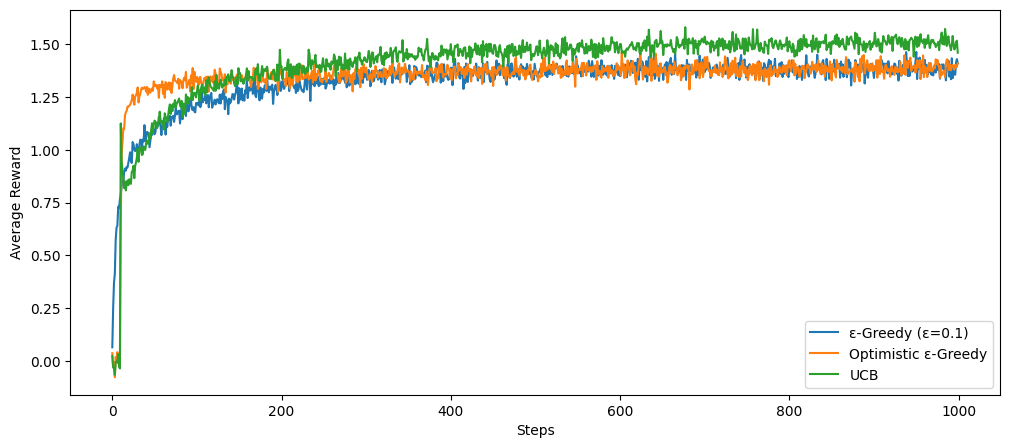

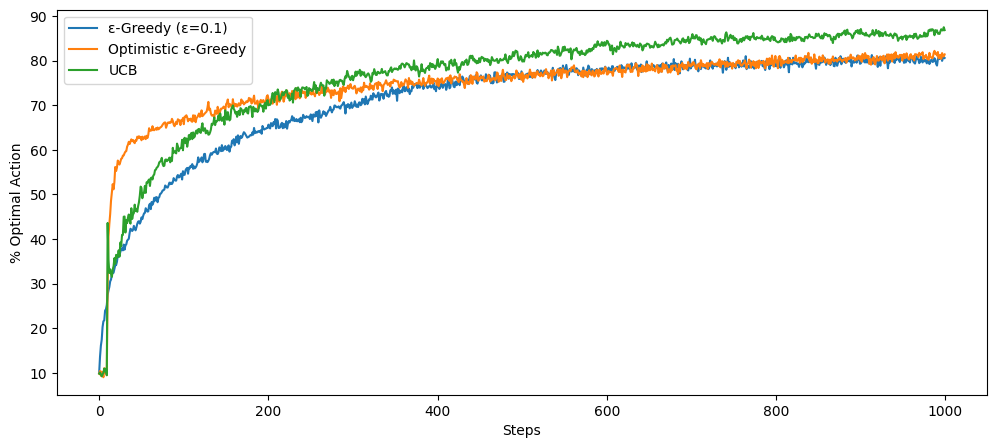

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class KArmedBandit:
    def __init__(self, k):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)
    
    def pull_arm(self, a):
        return np.random.normal(self.q_true[a], 1)

class EpsilonGreedyAgent:
    def __init__(self, k, epsilon):
        self.k = k
        self.epsilon = epsilon
        self.q_values = np.zeros(k)
        self.n_actions = np.zeros(k)
    
    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)
        return np.argmax(self.q_values) 
    
    def update(self, action, reward):
        self.n_actions[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.n_actions[action]

class OptimisticEpsilonGreedyAgent(EpsilonGreedyAgent):
    def __init__(self, k, epsilon, initial_value=5.0):
        super().__init__(k, epsilon)
        self.q_values.fill(initial_value)

class UCBAgent:
    def __init__(self, k, c):
        self.k = k
        self.c = c
        self.q_values = np.zeros(k)
        self.n_actions = np.zeros(k)
        self.time = 0
    
    def select_action(self):
        self.time += 1
        ucb_values = self.q_values + self.c * np.sqrt(np.log(self.time) / (self.n_actions + 1e-5))
        return np.argmax(ucb_values)
    
    def update(self, action, reward):
        self.n_actions[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.n_actions[action]

def experiment(k, steps, runs, agents):
    rewards = np.zeros((len(agents), steps))
    optimal_actions = np.zeros((len(agents), steps))
    
    for run in range(runs):
        bandit = KArmedBandit(k)
        optimal_action = np.argmax(bandit.q_true)
        agent_instances = [agent(k) for agent in agents]
        
        for t in range(steps):
            for i, agent in enumerate(agent_instances):
                action = agent.select_action()
                reward = bandit.pull_arm(action)
                agent.update(action, reward)
                
                rewards[i, t] += reward
                optimal_actions[i, t] += action == optimal_action
    
    rewards /= runs
    optimal_actions = (optimal_actions / runs) * 100
    return rewards, optimal_actions

def plot_results(rewards, optimal_actions, labels):
    plt.figure(figsize=(12, 5))
    for i, label in enumerate(labels):
        plt.plot(rewards[i], label=label)
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(12, 5))
    for i, label in enumerate(labels):
        plt.plot(optimal_actions[i], label=label)
    plt.xlabel("Steps")
    plt.ylabel("% Optimal Action")
    plt.legend()
    plt.show()

k = 10
steps = 1000
runs = 2000
agents = [lambda k: EpsilonGreedyAgent(k, 0.1),
          lambda k: OptimisticEpsilonGreedyAgent(k, 0.1, 5.0),
          lambda k: UCBAgent(k, 2.0)]
labels = ["ε-Greedy (ε=0.1)", "Optimistic ε-Greedy", "UCB"]

rewards, optimal_actions = experiment(k, steps, runs, agents)
plot_results(rewards, optimal_actions, labels)
